In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.797 sec
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 52)

In [19]:
from hoda.hoda import BTTDA
from sk learn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=32
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=128,
            tol=1e-6,
            init ='svd',
            shrinkage=(0.01,0.01),
            toeplitz=None,
            obj='diff',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            inverse=True,
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/32...
Initializing factors...
Estimating optimal rank...
Fitting discriminative tucker model of rank [1, 2] ...


  0%|          | 0/128 [00:00<?, ?it/s]


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     469.6
Date:                Thu, 24 Aug 2023   Prob (F-statistic):          9.35e-185
Time:                        12:34:55   Log-Likelihood:                -1389.9
No. Observations:                4200   AIC:                             2786.
Df Residuals:                    4197   BIC:                             2805.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1604      0.005     30.823      0.

  0%|          | 0/128 [00:00<?, ?it/s]


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     125.5
Date:                Thu, 24 Aug 2023   Prob (F-statistic):          4.67e-189
Time:                        12:34:55   Log-Likelihood:                -1363.1
No. Observations:                4200   AIC:                             2744.
Df Residuals:                    4191   BIC:                             2801.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1615      0.005     31.153      0.

...

  0%|          | 0/128 [00:00<?, ?it/s]


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     13.33
Date:                Thu, 24 Aug 2023   Prob (F-statistic):          6.34e-215
Time:                        12:35:14   Log-Likelihood:                -1104.1
No. Observations:                4200   AIC:                             2456.
Df Residuals:                    4076   BIC:                             3243.
Df Model:                         123                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1588      0.006     27.760      0.

  0%|          | 0/128 [00:00<?, ?it/s]


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     13.22
Date:                Thu, 24 Aug 2023   Prob (F-statistic):          1.82e-214
Time:                        12:35:15   Log-Likelihood:                -1103.8
No. Observations:                4200   AIC:                             2458.
Df Residuals:                    4075   BIC:                             3250.
Df Model:                         124                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1586      0.006     27.672      0.

BTTDA(hoda_params={'init': 'svd', 'inverse': True, 'keep_train_info': False,
                   'max_iter': 128, 'obj': 'diff', 'rank': None,
                   'shrinkage': (0.01, 0.01), 'solver': 'lanczos',
                   'taper': False, 'toeplitz': None, 'tol': 1e-06,
                   'verbose': True},
      keep_train_info=True, n_blocks=32, verbose=True)

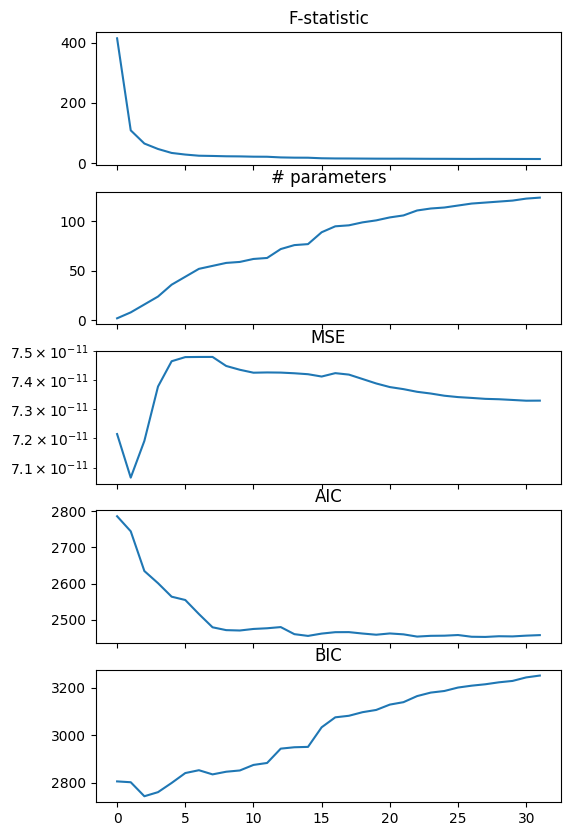

In [20]:
fig, axs = plt.subplots(5,1, sharex=True, figsize=(6,10))

axs[0].set_title('F-statistic')
axs[0].plot(bttda.train_info_["f_stat"])

axs[1].set_title('# parameters')
axs[1].plot(bttda.train_info_["n_params"])

axs[2].set_title('MSE')
axs[2].semilogy(bttda.train_info_["mse"])

axs[3].set_title('AIC')
axs[3].plot(bttda.train_info_["aic"])

axs[4].set_title('BIC')
axs[4].plot(bttda.train_info_["bic"])

In [7]:
import cupy

"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

"\nfig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))\nfor b in range(len(bttda.blocks_)):\n    for k in range(2):\n        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])\n        vmax = np.max(np.abs(scatter_w))\n        sns.heatmap(scatter_w, cmap='BrBG',\n                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    \n        axs[b,k].set_aspect('equal')\n"

No projector specified for this dataset. Please consider the method self.add_proj.


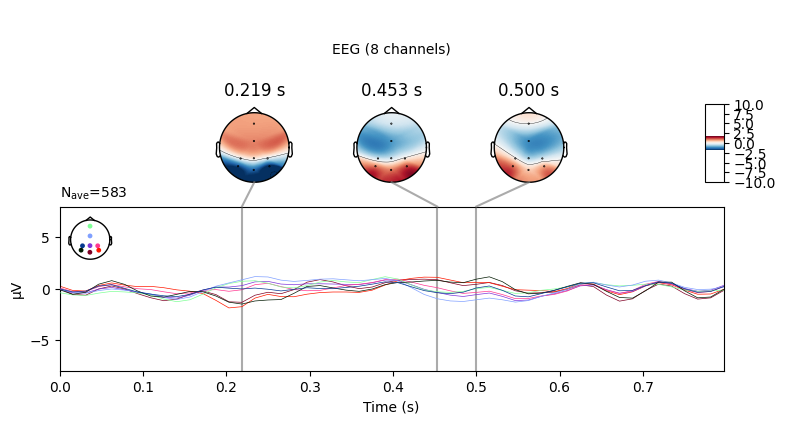

In [8]:
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-8,8])))


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

In [9]:
from mne import combine_evoked
""""
for b in range(len(bttda.blocks_)):
    epochs_rec = epochs.copy()
    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))
    
    target = epochs_rec['Target'].average()
    non_target = epochs_rec['NonTarget'].average()
    contrast = combine_evoked([target,non_target], weights=[1,-1])
    _ = contrast.plot_joint(**joint_args)
"""

'"\nfor b in range(len(bttda.blocks_)):\n    epochs_rec = epochs.copy()\n    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))\n    \n    target = epochs_rec[\'Target\'].average()\n    non_target = epochs_rec[\'NonTarget\'].average()\n    contrast = combine_evoked([target,non_target], weights=[1,-1])\n    _ = contrast.plot_joint(**joint_args)\n'